# Offshore wind NPV simulation

Run the offshore wind electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_technology_npv,
)


In [2]:
TECHNOLOGY = 'wind_offshore'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

rng = np.random.default_rng(RANDOM_SEED)
simulation = simulate_electricity_technology_npv(
    technology=TECHNOLOGY,
    size=SAMPLE_SIZE,
    rng=rng,
)
results = pd.DataFrame(simulation)

results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,3128.747258,46.965556,8.007400,0.0,...,94070000.0,1.219885e+07,8.007400e+06,0.0,0.0,7.386375e+07,-2.418258e+07,25000000.0,-0.967303,-9.673030e-07
1,1,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,2726.654128,47.243126,7.983493,0.0,...,94070000.0,1.227094e+07,7.983493e+06,0.0,0.0,7.381557e+07,7.974279e+07,25000000.0,3.189712,3.189712e-06
2,2,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,3230.317504,40.411169,9.274339,0.0,...,94070000.0,1.049641e+07,9.274339e+06,0.0,0.0,7.429925e+07,-4.591561e+07,25000000.0,-1.836624,-1.836624e-06
3,3,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,3036.841635,37.377099,8.386323,0.0,...,94070000.0,9.708337e+06,8.386323e+06,0.0,0.0,7.597534e+07,2.222971e+07,25000000.0,0.889188,8.891884e-07
4,4,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,2313.012817,42.988098,8.881936,0.0,...,94070000.0,1.116574e+07,8.881936e+06,0.0,0.0,7.402232e+07,1.893892e+08,25000000.0,7.575568,7.575568e-06


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh
count,100000.000000,100000.000000
mean,76.727797,3.069112
std,91.060125,3.642405
min,-122.666340,-4.906654
5%,-64.131935,-2.565277
50%,76.116860,3.044674
95%,218.370030,8.734801
max,269.781214,10.791249


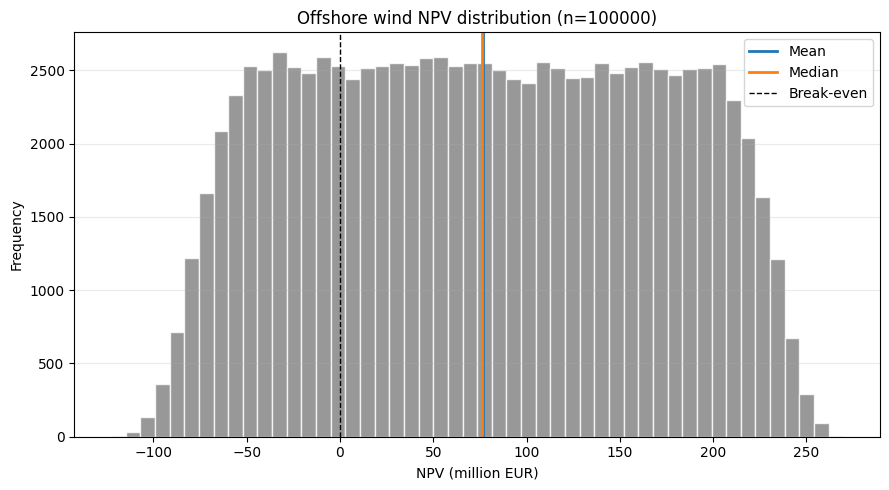

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Offshore wind NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


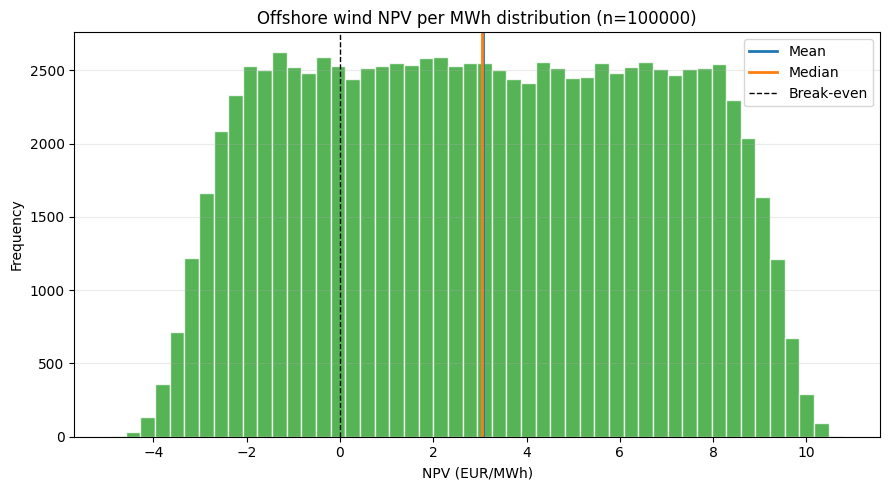

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Offshore wind NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        10.466056
annual_variable_opex_eur      8.267909
annual_fuel_cost_eur          0.000000
annual_emissions_cost_eur     0.000000
annual_net_cash_flow_eur     75.336035
Name: Mean annual value, million EUR, dtype: float64